In [2]:
#ライブラリーのインポート
import pandas as pd
import numpy as np
%matplotlib inline
#データの読み込み（タイタニックデータ）
df = pd.read_excel('titanic.xlsx')
#データを確認
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
#性別の数値変換
df.loc[(df['Sex'] == 'male'), 'Sex'] = 0
df.loc[(df['Sex'] == 'female'), 'Sex'] = 1
# 不要列の削除
df = df.drop(['Name','Cabin','Ticket','SibSp','Parch','Embarked','Fare'],axis=1)
df.head(10)

,PassengerId,Survived,Pclass,Sex,Age
0,1,0,3,0,22.0
1,2,1,1,1,38.0
2,3,1,3,1,26.0
3,4,1,1,1,35.0
4,5,0,3,0,35.0
5,6,0,3,0,NaN
6,7,0,1,0,54.0
7,8,0,3,0,2.0
8,9,1,3,1,27.0
9,10,1,2,1,14.0


In [7]:
df_cleaned = df.dropna()
df_cleaned.head(10)

,PassengerId,Survived,Pclass,Sex,Age
0,1,0,3,0,22.0
1,2,1,1,1,38.0
2,3,1,3,1,26.0
3,4,1,1,1,35.0
4,5,0,3,0,35.0
6,7,0,1,0,54.0
7,8,0,3,0,2.0
8,9,1,3,1,27.0
9,10,1,2,1,14.0
10,11,1,3,1,4.0


In [8]:
mean = df.mean()
df_mean = df.fillna(mean)
df_mean.head(10)

C:\Users\masat\AppData\Local\Temp\ipykernel_34040\1764189280.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mean = df.fillna(mean)


,PassengerId,Survived,Pclass,Sex,Age
0,1,0,3,0,22.000000
1,2,1,1,1,38.000000
2,3,1,3,1,26.000000
3,4,1,1,1,35.000000
4,5,0,3,0,35.000000
5,6,0,3,0,29.699118
6,7,0,1,0,54.000000
7,8,0,3,0,2.000000
8,9,1,3,1,27.000000
9,10,1,2,1,14.000000


In [9]:
from sklearn.linear_model import LinearRegression
df_master = df.dropna()
df_miss = df[df.isnull().any(axis=1)]
#欠損値がある列「Age」を目的変数として、「Passengerld, Pclass, Sex」を説明変数にして、線形回帰モデルを構築
model = LinearRegression().fit(df_master.drop(["Age","Survived"], axis=1), df_master["Age"])
# 線形回帰モデルで欠損値を予測
df_miss["Age"] = model.predict(df_miss.drop(["Age","Survived"], axis=1))
df_LR = pd.concat([df_master, df_miss]).sort_index()
df_LR.head(10)

C:\Users\masat\AppData\Local\Temp\ipykernel_34040\206712107.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_miss["Age"] = model.predict(df_miss.drop(["Age","Survived"], axis=1))


,PassengerId,Survived,Pclass,Sex,Age
0,1,0,3,0,22.000000
1,2,1,1,1,38.000000
2,3,1,3,1,26.000000
3,4,1,1,1,35.000000
4,5,0,3,0,35.000000
5,6,0,3,0,25.726147
6,7,0,1,0,54.000000
7,8,0,3,0,2.000000
8,9,1,3,1,27.000000
9,10,1,2,1,14.000000


In [10]:
from sklearn.impute import KNNImputer
imp = KNNImputer(n_neighbors=2, weights='uniform')
df_KNN = pd.DataFrame(imp.fit_transform(df))
df_KNN.columns = df.columns
df_KNN.head(10)

,PassengerId,Survived,Pclass,Sex,Age
0,1.0,0.0,3.0,0.0,22.0
1,2.0,1.0,1.0,1.0,38.0
2,3.0,1.0,3.0,1.0,26.0
3,4.0,1.0,1.0,1.0,35.0
4,5.0,0.0,3.0,0.0,35.0
5,6.0,0.0,3.0,0.0,18.5
6,7.0,0.0,1.0,0.0,54.0
7,8.0,0.0,3.0,0.0,2.0
8,9.0,1.0,3.0,1.0,27.0
9,10.0,1.0,2.0,1.0,14.0


In [11]:
imp = KNNImputer(n_neighbors=2, weights='distance')
df_KNN = pd.DataFrame(imp.fit_transform(df))
df_KNN.columns = df.columns
df_KNN.head(10)

,PassengerId,Survived,Pclass,Sex,Age
0,1.0,0.0,3.0,0.0,22.0
1,2.0,1.0,1.0,1.0,38.0
2,3.0,1.0,3.0,1.0,26.0
3,4.0,1.0,1.0,1.0,35.0
4,5.0,0.0,3.0,0.0,35.0
5,6.0,0.0,3.0,0.0,24.0
6,7.0,0.0,1.0,0.0,54.0
7,8.0,0.0,3.0,0.0,2.0
8,9.0,1.0,3.0,1.0,27.0
9,10.0,1.0,2.0,1.0,14.0


In [12]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
#ワインのデータセットを読み込む
wine = load_wine()
#各特徴量を抽出
data = pd.DataFrame(wine["data"], columns = wine["feature_names"])
#ラベルの抽出
label = pd.DataFrame(wine["target"], columns=["label"])
print(data.shape)
data.head()

(178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [14]:
# ライブラリのインポート
from sklearn.model_selection import train_test_split
#トレーニングセットとテストセットに7:3の比率で分割する
train_x, test_x, train_y, test_y = train_test_split(data, label, test_size=0.3,stratify=label,random_state=2)

In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#正規化のクラスを生成
mmsc = MinMaxScaler()
#標準化のクラスを生成
stdsc = StandardScaler()

#訓練用のデータを正規化
train_mm = mmsc.fit_transform(train_x)
#訓練用のデータを標準化
train_std = stdsc.fit_transform(train_x)
#訓練用データを基にテストデータを正規化
test_mm=mmsc.transform(test_x)
#訓練用データを基にテストデータを標準化
test_std = stdsc.transform(test_x)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
#元のデータ用
lr = KNeighborsClassifier(n_neighbors=3)
#正規化したデータ用
lr_mm = KNeighborsClassifier(n_neighbors=3)
#標準化したデータ用
lr_std = KNeighborsClassifier(n_neighbors=3)
#元のデータの適用
lr.fit(train_x, train_y)
#正規化したデータの適用
lr_mm.fit(train_mm, train_y)
#標準化したデータの適用
lr_std.fit(train_std, train_y)


print('元のデータのスコア :',lr.score(test_x, test_y))
print('正規化したデータのスコア :',lr_mm.score(test_mm, test_y))
print('標準化したデータのスコア :',lr_std.score(test_std, test_y))

元のデータのスコア : 0.7222222222222222
正規化したデータのスコア : 0.9444444444444444
標準化したデータのスコア : 0.9259259259259259


C:\Users\masat\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\masat\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\masat\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


オリジナルのクラス分布：
1    900
0    100
Name: count, dtype: int64


C:\Users\masat\AppData\Local\Temp\ipykernel_34040\3020217962.py:10: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(y))


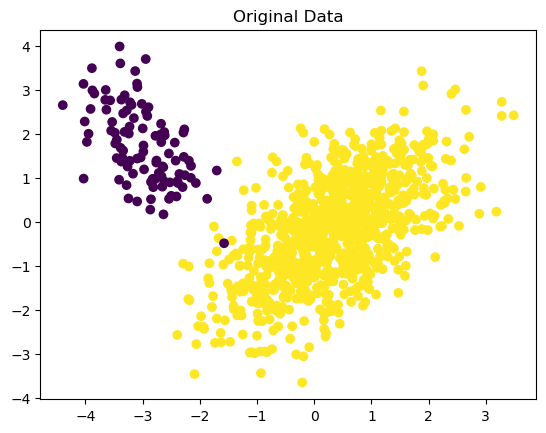

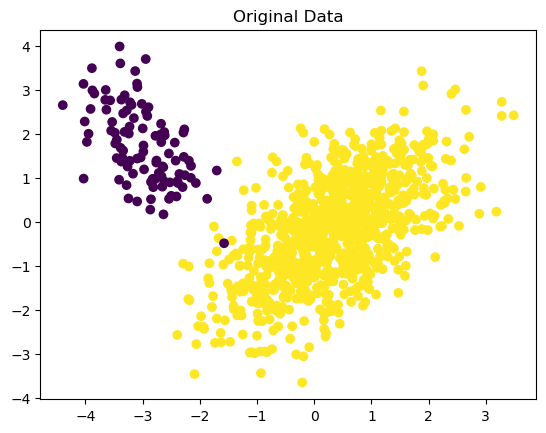

In [21]:
from sklearn.datasets import make_classification
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
#人工的な不均衡データを生成
X,y = make_classification(n_classes=2,class_sep=2,weights=[0.1,0.9],n_informative=3,n_redundant=1,flip_y=0,n_features=20,n_clusters_per_class=1,n_samples=1000,random_state=42)

#データセットのクラス分布を表示
print("オリジナルのクラス分布：")
print(pd.value_counts(y))
#PCAによる可視化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,1],c=y)
plt.title('Original Data')
plt.show()

¥nアンダーサンプリング後のクラス分布：
0    100
1    100
Name: count, dtype: int64


C:\Users\masat\AppData\Local\Temp\ipykernel_34040\2258564250.py:7: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(y_rus))


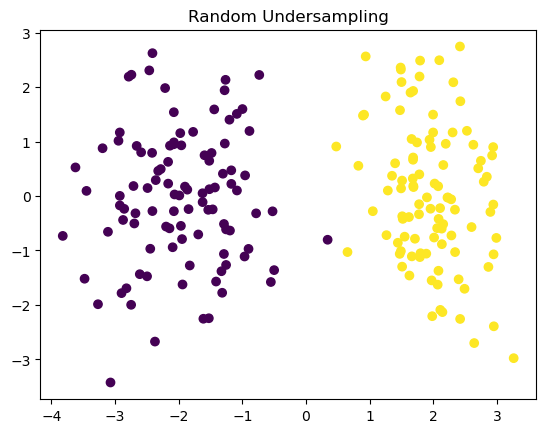

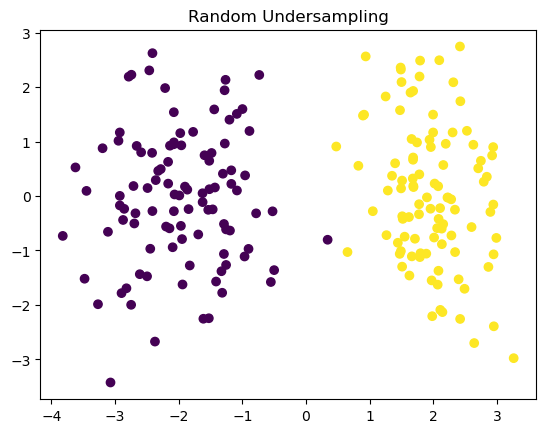

In [23]:
from imblearn.under_sampling import RandomUnderSampler
# アンダーサンプリング
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)
#データセットのクラス分布を表示
print("¥nアンダーサンプリング後のクラス分布：")
print(pd.value_counts(y_rus))
# PCAによる可視化
pca = PCA(n_components=2)
X_rus_pca = pca.fit_transform(X_rus)
plt.figure()
plt.scatter(X_rus_pca[:,0],X_rus_pca[:,1],c=y_rus)
plt.title('Random Undersampling')
plt.show()

¥nオーバーサンプリング後のクラス分布：
1    900
0    900
Name: count, dtype: int64


C:\Users\masat\AppData\Local\Temp\ipykernel_34040\134925659.py:7: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(y_ros))


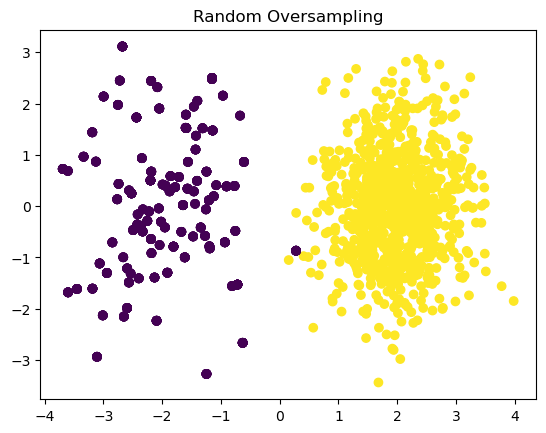

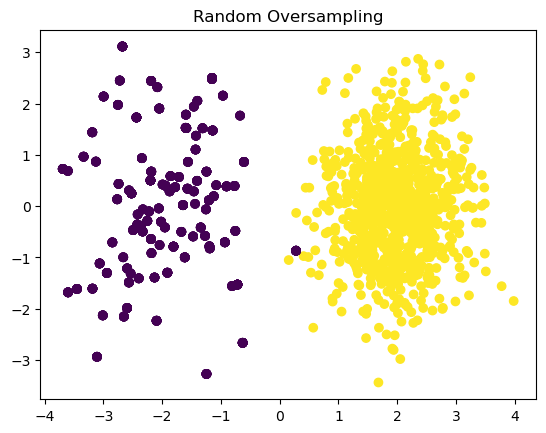

In [25]:
from imblearn.over_sampling import RandomOverSampler
#オーバーサンプリング
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)
#データセットのクラス分布を表示
print("¥nオーバーサンプリング後のクラス分布：")
print(pd.value_counts(y_ros))
#PCAによる可視化
pca = PCA(n_components=2)
X_ros_pca = pca.fit_transform(X_ros)
plt.figure()
plt.scatter(X_ros_pca[:,0],X_ros_pca[:,1],c=y_ros)
plt.title('Random Oversampling')
plt.show()

¥nSmote後のクラス分布：
1    900
0    900
Name: count, dtype: int64


C:\Users\masat\AppData\Local\Temp\ipykernel_34040\3462903588.py:7: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(y_smote))


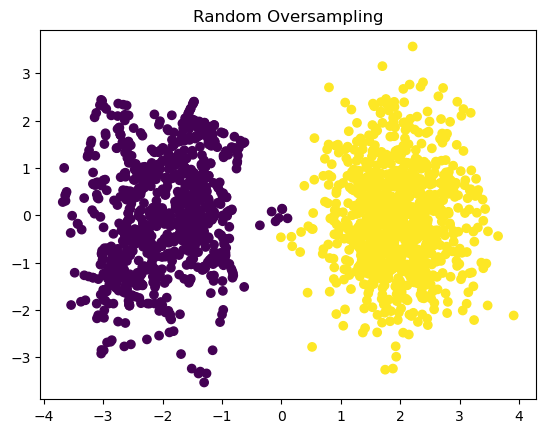

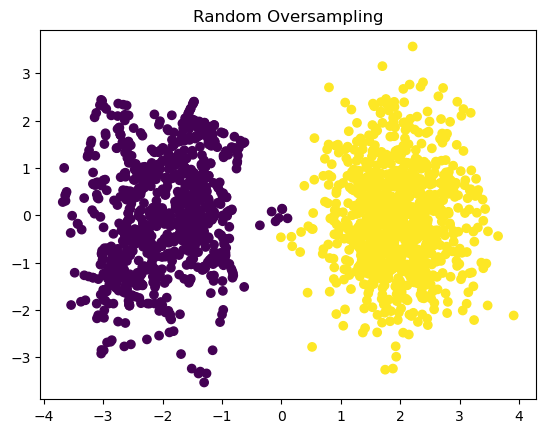

In [27]:
from imblearn.over_sampling import SMOTE
#SMOTEの適用
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)
#データセットのクラス分布を表示
print("¥nSmote後のクラス分布：")
print(pd.value_counts(y_smote))
#PCAによる可視化
pca = PCA(n_components=2)
X_smote_pca = pca.fit_transform(X_smote)
plt.figure()
plt.scatter(X_smote_pca[:,0],X_smote_pca[:,1], c=y_smote)
plt.title('Random Oversampling')
plt.show()

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#データのダウンロード
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+",skiprows=22,header=None)
data = np.hstack([raw_df.values[::2,:], raw_df.values[1::2,:2],raw_df.values[1::2,2].reshape(-1,1)])
#列名を追加
column_names = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']
df = pd.DataFrame(data, columns=column_names) 
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [30]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [38]:
import numpy as np
from scipy import linalg

from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from sklearn.utils import check_array
from sklearn.base import BaseEstimator, TransformerMixin


class LocalityPreservingProjection(BaseEstimator, TransformerMixin):
    """Locality Preserving Projection

    Parameters
    ----------
    n_components : integer
        number of coordinates for the manifold

    n_neighbors : integer
        number of neighbors to consider for each point.

    weight : string ['adjacency'|'heat']
        Weight function to use for the mapping

    weight_width : float
        Width of the heat kernel for building the weight matrix.
        Only referenced if weights == 'heat'

    neighbors_algorithm : string ['auto'|'brute'|'kd_tree'|'ball_tree']
        Algorithm to use for nearest neighbors search,
        passed to neighbors.NearestNeighbors instance.

    Attributes
    ----------
    projection_ : array-like, shape (n_features, n_components)
        Linear projection matrix for the embedding
    """
    def __init__(self, n_components=2, n_neighbors=5,
                 weight='adjacency', weight_width=1.0,
                 neighbors_algorithm='auto'):
        # TODO: allow radius neighbors
        # TODO: allow for precomputed weights
        self.n_components = n_components
        self.n_neighbors = n_neighbors
        self.weight = weight
        self.weight_width = weight_width
        self.neighbors_algorithm = neighbors_algorithm

    def fit(self, X, y=None):
        X = check_array(X)
        W = self._compute_weights(X)
        self.projection_ = self._compute_projection(X, W)
        return self

    def transform(self, X):
        X = check_array(X)
        return np.dot(X, self.projection_)

    def _compute_projection(self, X, W):
        """Compute the LPP projection matrix

        Parameters
        ----------
        X : array_like, (n_samples, n_features)
            The input data
        W : array_like or sparse matrix, (n_samples, n_samples)
            The precomputed adjacency matrix

        Returns
        -------
        P : ndarray, (n_features, self.n_components)
            The matrix encoding the locality preserving projection
        """
        # TODO: check W input; handle sparse case
        X = check_array(X)

        D = np.diag(W.sum(1))
        L = D - W
        evals, evecs = eigh_robust(np.dot(X.T, np.dot(L, X)),
                                   np.dot(X.T, np.dot(D, X)),
                                   eigvals=(0, self.n_components - 1))
        return evecs

    def _compute_weights(self, X):
        X = check_array(X)
        self.nbrs_ = NearestNeighbors(n_neighbors=self.n_neighbors,
                                      algorithm=self.neighbors_algorithm)
        self.nbrs_.fit(X)

        if self.weight == 'adjacency':
            W = kneighbors_graph(self.nbrs_, self.n_neighbors,
                                 mode='connectivity', include_self=True)
        elif self.weight == 'heat':
            W = kneighbors_graph(self.nbrs_, self.n_neighbors,
                                 mode='distance', include_self=True)
            W.data = np.exp(-W.data ** 2 / self.weight_width ** 2)
        else:
            raise ValueError("Unrecognized Weight")

        # symmetrize the matrix
        # TODO: make this more efficient & keep sparse output
        W = W.toarray()
        W = np.maximum(W, W.T)
        return W


def eigh_robust(a, b=None, eigvals=None, eigvals_only=False,
                overwrite_a=False, overwrite_b=False,
                turbo=True, check_finite=True):
    """Robustly solve the Hermitian generalized eigenvalue problem

    This function robustly solves the Hermetian generalized eigenvalue problem
    ``A v = lambda B v`` in the case that B is not strictly positive definite.
    When B is strictly positive-definite, the result is equivalent to
    scipy.linalg.eigh() within floating-point accuracy.

    Parameters
    ----------
    a : (M, M) array_like
        A complex Hermitian or real symmetric matrix whose eigenvalues and
        eigenvectors will be computed.
    b : (M, M) array_like, optional
        A complex Hermitian or real symmetric matrix.
        If omitted, identity matrix is assumed.
    eigvals : tuple (lo, hi), optional
        Indexes of the smallest and largest (in ascending order) eigenvalues
        and corresponding eigenvectors to be returned: 0 <= lo <= hi <= M-1.
        If omitted, all eigenvalues and eigenvectors are returned.
    eigvals_only : bool, optional
        Whether to calculate only eigenvalues and no eigenvectors.
        (Default: both are calculated)
    turbo : bool, optional
        Use divide and conquer algorithm (faster but expensive in memory,
        only for generalized eigenvalue problem and if eigvals=None)
    overwrite_a : bool, optional
        Whether to overwrite data in `a` (may improve performance)
    overwrite_b : bool, optional
        Whether to overwrite data in `b` (may improve performance)
    check_finite : bool, optional
        Whether to check that the input matrices contain only finite numbers.
        Disabling may give a performance gain, but may result in problems
        (crashes, non-termination) if the inputs do contain infinities or NaNs.

    Returns
    -------
    w : (N,) float ndarray
        The N (1<=N<=M) selected eigenvalues, in ascending order, each
        repeated according to its multiplicity.
    v : (M, N) complex ndarray
        (if eigvals_only == False)
    """
    #kwargs = dict(eigvals=eigvals, eigvals_only=eigvals_only,
    #              turbo=turbo, check_finite=check_finite,
    #              overwrite_a=overwrite_a, overwrite_b=overwrite_b)
    kwargs = dict(subset_by_index=eigvals, eigvals_only=eigvals_only,
                  check_finite=check_finite,
                  overwrite_a=overwrite_a, overwrite_b=overwrite_b)

    # Check for easy case first:
    if b is None:
        return linalg.eigh(a, **kwargs)

    # Compute eigendecomposition of b
    #kwargs_b = dict(turbo=turbo, check_finite=check_finite,
    #                overwrite_a=overwrite_b)  # b is a for this operation
    kwargs_b = dict(check_finite=check_finite,
                    overwrite_a=overwrite_b)  # b is a for this operation
    
    S, U = linalg.eigh(b, **kwargs_b)

    # Combine a and b on left hand side via decomposition of b
    S[S <= 0] = np.inf
    Sinv = 1. / np.sqrt(S)
    W = Sinv[:, None] * np.dot(U.T, np.dot(a, U)) * Sinv
    output = linalg.eigh(W, **kwargs)

    if eigvals_only:
        return output
    else:
        evals, evecs = output
        return evals, np.dot(U, Sinv[:, None] * evecs)


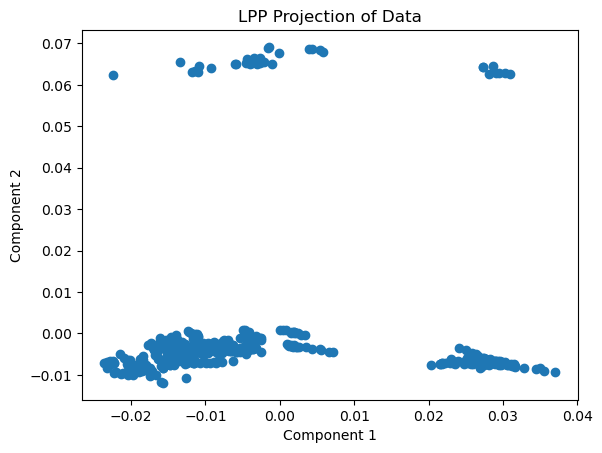

In [47]:
#データの標準化 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df)
#LPPを使用して次元削減

#LPPを実行
lpp = LocalityPreservingProjection(n_components=2)
X_2D = lpp.fit_transform(X)
#低次元データを可視化
plt.figure()
plt.scatter(X_2D[:, 0], X_2D[:, 1]) 
plt.title('LPP Projection of Data')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

C:\Users\masat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


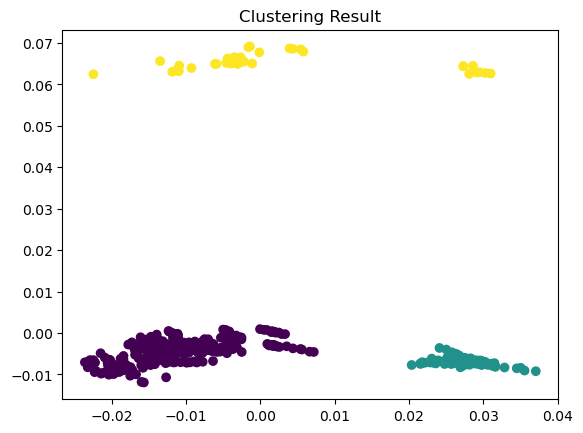

In [48]:
from sklearn.cluster import KMeans
#低次元で、K-Meansクラスタリングを実行
model = KMeans(n_clusters=3, random_state=42)
cluster = model.fit_predict(X_2D)
#結果を可視化
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=cluster)
plt.title('Clustering Result')
plt.show()

In [49]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.01) 
lasso.fit(X, cluster)
#係数の取得
coefficients = lasso.coef_
#係数の絶対値に基づく特徴量の重要性を取得
feature_importance = np.abs(coefficients)
# 重要性でソートされた特徴量のインデックスを取得
sorted_index = np.argsort(feature_importance)[::-1]
# ソートされた特徴量の名前と重要性を出力
print("Feature importance sorted:")
for idx in sorted_index:
    print(f"{column_names[idx]}: {feature_importance[idx]}")

Feature importance sorted:
CHAS: 0.4361118012830237
RAD: 0.37613850484677425
CRIM: 0.013410220265881756
LSTAT: 0.012772785293287015
B: 0.006132504067000263
MEDV: 0.0057626976324294
INDUS: 0.0014903047618283409
PTRATIO: 0.0
TAX: 0.0
DIS: 0.0
NOX: 0.0
RM: 0.0
AGE: 0.0
ZN: 0.0


C:\Users\masat\AppData\Local\Temp\ipykernel_34040\3944177124.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = cluster


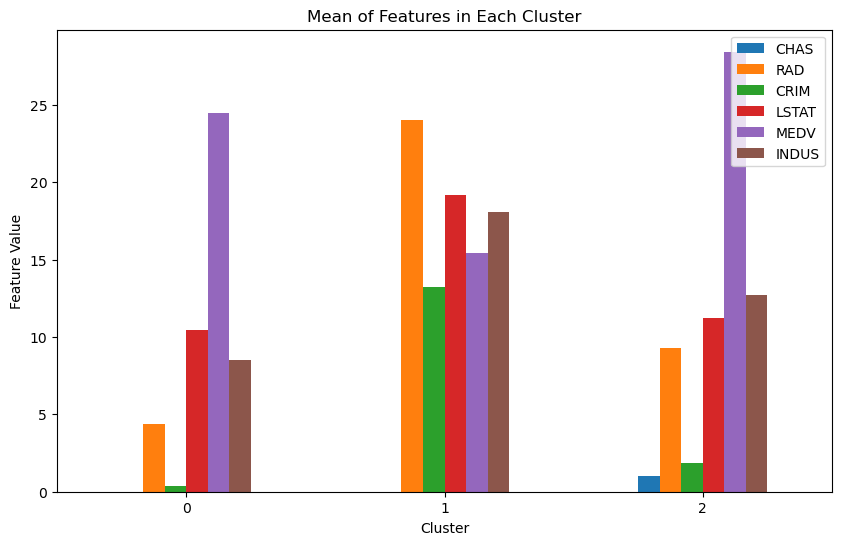

In [50]:
#選択した特徴量
#columns = ['RAD','CHAS','CRIM','LSTAT','MEDV','ZN','INDUS']
columns = ['CHAS','RAD','CRIM','LSTAT','MEDV','INDUS']
df = df[columns]
#選択した特徴量でのクラスタ毎の平均値を計算，結果を棒グラフに反映
df['cluster'] = cluster 
cluster_means = df.groupby('cluster').mean()
cluster_means[columns].plot(kind='bar', figsize=(10, 6))
plt.title('Mean of Features in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Feature Value')
plt.xticks(rotation=0) 
plt.legend(loc='upper right')
plt.show()

In [68]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

data = load_breast_cancer()
X = data.data
y = data.target
#print(X.shape)
#print(y.shape)
data_df = pd.DataFrame(X, columns=data.feature_names)
#print(data_df.head())
#print(data_df.info())

stdsc = StandardScaler()
X_std = stdsc.fit_transform(data_df)
mmdsc = MinMaxScaler()
X_mm = mmdsc.fit_transform(data_df)

lr = KNeighborsClassifier(n_neighbors=3)
lr_mm = KNeighborsClassifier(n_neighbors=3)
lr_std = KNeighborsClassifier(n_neighbors=3)
lr.fit(data_df, y)
lr_mm.fit(X_mm, y)
lr_std.fit(X_std, y)


#print('元のデータのスコア :',lr.score(data_df, y))
#print('正規化したデータのスコア :',lr_mm.score(X_mm, y))
#print('標準化したデータのスコア :',lr_std.score(X_std, y))

import numpy as np
#print(np.sum(y==0),np.sum(y==1))
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_mm)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_pca)
cluster_mean = pd.DataFrame(data_df, columns=data_df.columns)
cluster_mean["cluster"] = labels
result = cluster_mean.groupby("cluster").mean().T
print(result)
df_cluster = pd.DataFrame({"cluster": labels,"label": y})
count_table = df_cluster.groupby("cluster")["label"].value_counts().unstack(fill_value=0)
ratio_table = count_table.div(count_table.sum(axis=1), axis=0)
print("良性(0)と悪性(1)の数：")
print(count_table)
print("\n良性(0)と悪性(1)の比率：")
print(ratio_table)

cluster                            0           1           2
mean radius                19.806161   12.419307   13.924677
mean texture               21.957500   18.220499   20.197604
mean perimeter            131.220536   79.712881   92.263854
mean area                1236.410714  486.512742  609.612500
mean smoothness             0.101661    0.091406    0.108807
mean compactness            0.152468    0.074497    0.160419
mean concavity              0.185464    0.040451    0.157833
mean concave points         0.105675    0.025184    0.071959
mean symmetry               0.192246    0.172283    0.201619
mean fractal dimension      0.060663    0.061506    0.070144
radius error                0.784693    0.290909    0.392075
texture error               1.248063    1.208624    1.211389
perimeter error             5.573027    2.017296    2.899635
area error                102.880893   22.537230   34.304146
smoothness error            0.006720    0.006951    0.007755
compactness error       

C:\Users\masat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [29]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 